In [226]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

In [227]:
path = "C:\\Users\\huynh\\Downloads\\tonghop"
IMG_SIZE = (180,180)
BATCH_SIZE = 32
SEED = 42

In [228]:
train = keras.utils.image_dataset_from_directory(
    path,
    batch_size = BATCH_SIZE,
    image_size = IMG_SIZE,
    seed = SEED,
    validation_split = 0.2,
    subset = "training"
)

Found 4433 files belonging to 3 classes.
Using 3547 files for training.


In [229]:
val = keras.utils.image_dataset_from_directory(
    path,
    batch_size = BATCH_SIZE,
    image_size = IMG_SIZE,
    seed = SEED,
    validation_split = 0.2,
    subset = "validation"
)

Found 4433 files belonging to 3 classes.
Using 886 files for validation.


In [230]:
class_names = train.class_names
class_names

['paper', 'rock', 'scissors']

In [231]:
for image_batch, labels_batch in train:
    print(image_batch.shape)
    print(labels_batch.shape)
    break

(32, 180, 180, 3)
(32,)


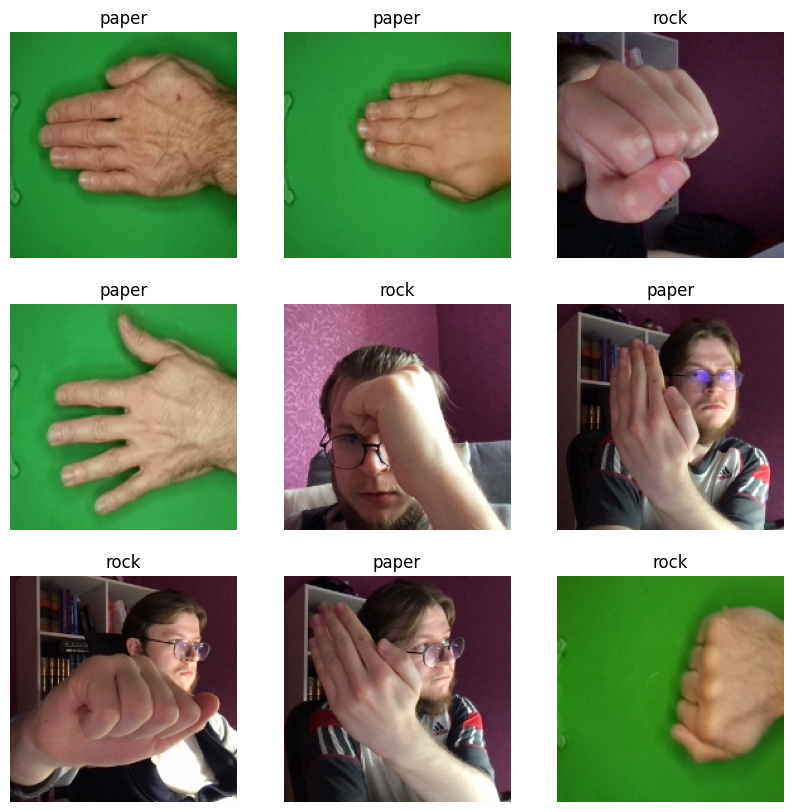

In [232]:
plt.figure(figsize=(10, 10))
for images, labels in train.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [233]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal_and_vertical", seed=42),
  tf.keras.layers.RandomRotation(0.1, seed=42),
])

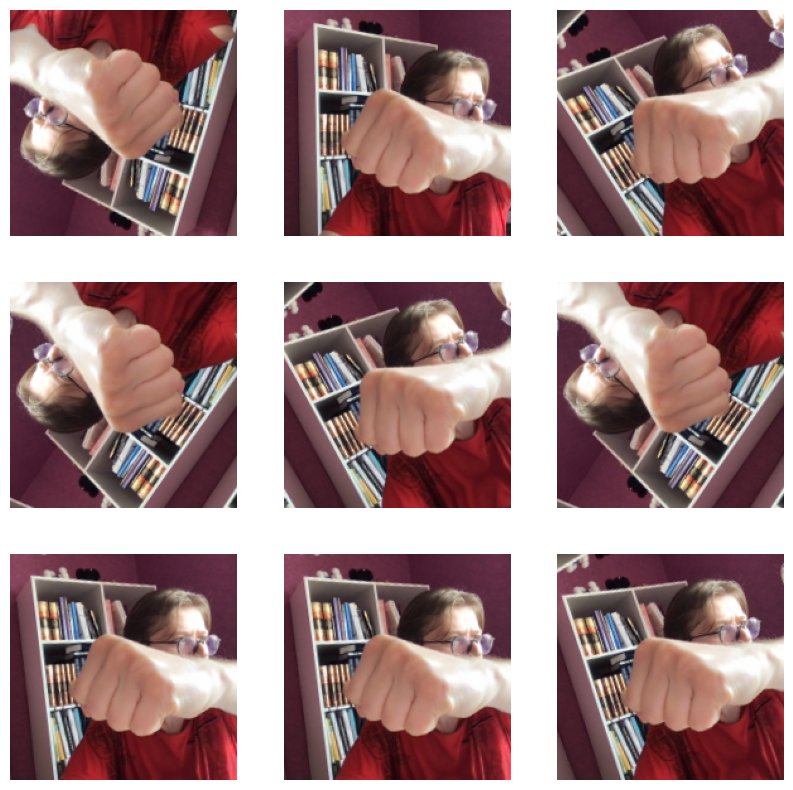

In [234]:
plt.figure(figsize=(10, 10))
for images, _ in train.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[0].numpy().astype("uint8"))
        plt.axis("off")

In [238]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape = (180,180,3)),
    tf.keras.layers.Rescaling(1./255),
    data_augmentation,
    
    tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),
   
    tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    
    tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),
   
    tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    
    tf.keras.layers.Flatten(),
    
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(3)
])

In [239]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

model.summary()

early_stop = keras.callbacks.EarlyStopping(monitor = "val_loss", mode = "auto", patience = 3, verbose = 1, restore_best_weights=False)

Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_22 (Rescaling)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_25 (Sequential)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_88 (Conv2D)              │ (None, 180, 180, 128)  │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_88 (MaxPooling2D) │ (None, 90, 90, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_89 (Conv2D)              │ (None, 90, 90, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_89 (MaxPooling2D) │ (None, 45, 45, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_90 (Conv2D)              │ (None, 45, 45, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_90 (MaxPooling2D) │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_91 (Conv2D)              │ (None, 22, 22, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_91 (MaxPooling2D) │ (None, 11, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 15488)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 512)            │     7,930,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,378,243 (31.96 MB)

 Trainable params: 8,378,243 (31.96 MB)

 Non-trainable params: 0 (0.00 B)

In [240]:
history = model.fit(train, epochs=50, validation_data = val, callbacks=[early_stop])

Epoch 1/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.3366 - loss: 1.1024 - val_accuracy: 0.3409 - val_loss: 1.0885
Epoch 2/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.3702 - loss: 1.0913 - val_accuracy: 0.4639 - val_loss: 1.0038
Epoch 3/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.5168 - loss: 0.9130 - val_accuracy: 0.6569 - val_loss: 0.6823
Epoch 4/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.6820 - loss: 0.6550 - val_accuracy: 0.7167 - val_loss: 0.5867
Epoch 5/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.7324 - loss: 0.5681 - val_accuracy: 0.7370 - val_loss: 0.5744
Epoch 6/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.7787 - loss: 0.4887 - val_accuracy: 0.7765 - val_loss: 0.5385
Epoch 7/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.8105 - loss: 0.4321 - val_accuracy: 0.7720 - val_loss: 0.5810
Epoch 8/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.8300 - loss: 0.4031 - val_accu

In [241]:
from pathlib import Path
save_dir = Path('models')
save_dir.mkdir(exist_ok=True) 

model_path = save_dir / 'testkeobuabao1.keras'
model.save(model_path)

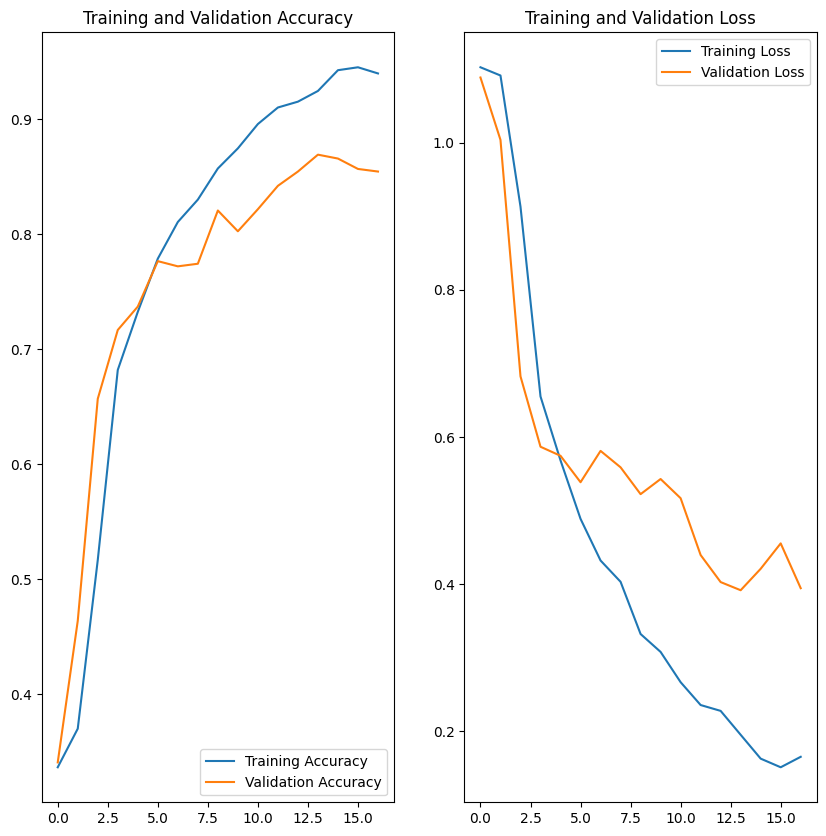

In [242]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(10,10))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [247]:
import numpy as np
import cv2 
from tensorflow import keras

model = keras.models.load_model("C:\\Users\\huynh\\Documents\\ML\\models\\testkeobuabao1.keras")
class_name = ["Bao", "Bua", "Keo"]

img_path = "C:\\Users\\huynh\\Downloads\\7c293123-1636-4f5e-8062-be49d1d441d7.jpg"
img = cv2.imread(img_path)

img_resize = cv2.resize(img, IMG_SIZE)
img_color = cv2.cvtColor(img_resize, cv2.COLOR_BGR2RGB)

img_input = np.expand_dims(img_color, axis = 0)

predict = model.predict(img_input, verbose = 0)
label = class_name[np.argmax(predict)]
score = np.max(predict)

print(f"ket qua: {label}, ti le: {score}")

ket qua: Bao, ti le: 1.3537559509277344


In [ ]:
import cv2
import numpy as np
from tensorflow import keras

# 1. Nạp mô hình đã train (Mô hình nhận ảnh xám 1 kênh màu)
model = keras.models.load_model('models/testkeobuabao1.keras')
class_names = ['Bao', 'Bua', 'Keo'] # Đảm bảo đúng thứ tự Alphabet

cap = cv2.VideoCapture(0)
q
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        print("Không thể kết nối với camera.")
        break

    # --- BƯỚC 1: TIỀN XỬ LÝ ẢNH (Phải khớp 100% với lúc Train) ---
    h, w, _ = frame.shape
    max_dim = max(h, w)
    
    # Bù viền đen để tạo ảnh vuông (giữ nguyên tỷ lệ tay)
    top = (max_dim - h) // 2
    bottom = max_dim - h - top
    left = (max_dim - w) // 2
    right = max_dim - w - left
    square_frame = cv2.copyMakeBorder(frame, top, bottom, left, right, cv2.BORDER_CONSTANT, value=[0, 0, 0])
    
    # Thu nhỏ về 224x224
    img_resized = cv2.resize(square_frame, (180,180))
    
    # TƯỚC BỎ MÀU SẮC: Chuyển sang ảnh xám (Tuyệt chiêu chống Overfit phông xanh)
    img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    
    # Định dạng lại ma trận: Từ (224, 224) -> (224, 224, 1) -> (1, 224, 224, 1)
    img_input = np.expand_dims(img_gray, axis=-1) # Thêm kênh màu (1 kênh)
    img_input = np.expand_dims(img_input, axis=0)  # Thêm chiều lô (Batch = 1)

    # --- BƯỚC 2: DỰ ĐOÁN ---
    prediction = model.predict(img_input, verbose=0)
    score = np.max(prediction)
    label = class_names[np.argmax(prediction)]

    # --- BƯỚC 3: HIỂN THỊ KẾT QUẢ ---
    # In chữ lên màn hình màu gốc cho đẹp
    # Lấy ra mảng xác suất của cả 3 class
    predictions = model.predict(img_input, verbose=0)[0] 
    
    # Sắp xếp các điểm số từ cao xuống thấp
    sorted_indices = np.argsort(predictions)[::-1]
    top1_score = predictions[sorted_indices[0]]
    top2_score = predictions[sorted_indices[1]]
    top1_label = class_names[sorted_indices[0]]

    # ĐIỀU KIỆN KÉP: Điểm cao nhất phải > 70% VÀ cách biệt với top 2 ít nhất 30%
    if top1_score > 0.70 and (top1_score - top2_score) > 0.30:
        label = top1_label
        color = (0, 255, 0) # Xanh lá
        text = f"{label}: {top1_score*100:.1f}%"
    else:
        label = "Khong ro"
        color = (0, 0, 255) # Đỏ
        text = "Dang tim ban tay..."

    cv2.putText(frame, text, (30, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)
    
    # HIỂN THỊ CỬA SỔ CHÍNH (Màu thật)
    cv2.imshow('Camera Thuc Te', frame)
    
    # VŨ KHÍ BÍ MẬT: HIỂN THỊ CỬA SỔ CỦA AI (Ảnh Xám)
    # Cửa sổ này cho thầy cô thấy chính xác AI đang nhìn thấy gì
    cv2.imshow('Goc Nhin Cua AI (Grayscale)', img_gray)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

NameError: name 'q' is not defined